# Task 1: Diagnostic Enhancement of Chest X-Rays



**Scenario:** Raw chest X-rays acquired for a pneumonia-detection pipeline are severely underexposed, hiding lung cavities and fluid build-up. This notebook mathematically enhances a single-channel X-ray matrix so structures become visible before the image reaches a diagnostic reviewer.



**Sample image:** `data/sample_xray.png` (one PNEUMONIA-class image from the COVID19+PNEUMONIA+NORMAL Chest X-Ray dataset). All paths below are relative.

In [1]:
import cv2

import numpy as np

import matplotlib.pyplot as plt

import os



DATA_PATH = 'data/sample_xray.png'

OUTPUT_DIR = 'output'

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load and Display

Load the sample X-ray strictly as a single-channel grayscale matrix.

Shape: (232, 232) | dtype: uint8 | min/max: 0 206


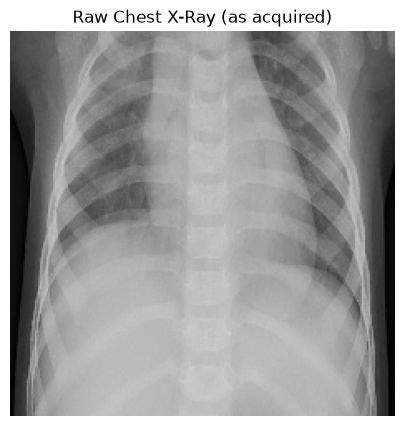

In [2]:
raw = cv2.imread(DATA_PATH, cv2.IMREAD_GRAYSCALE)

assert raw is not None, f'Could not load {DATA_PATH}'

print('Shape:', raw.shape, '| dtype:', raw.dtype, '| min/max:', raw.min(), raw.max())



plt.figure(figsize=(5, 5))

plt.imshow(raw, cmap='gray', vmin=0, vmax=255)

plt.title('Raw Chest X-Ray (as acquired)')

plt.axis('off')

plt.savefig(f'{OUTPUT_DIR}/01_raw.png', bbox_inches='tight')

plt.show()

## 2. Contrast Enhancement (Histogram Equalization)

Histogram equalization forcefully redistributes pixel intensities across the full 0-255 range, pulling structure out of the narrow intensity band an underexposed X-ray is compressed into.

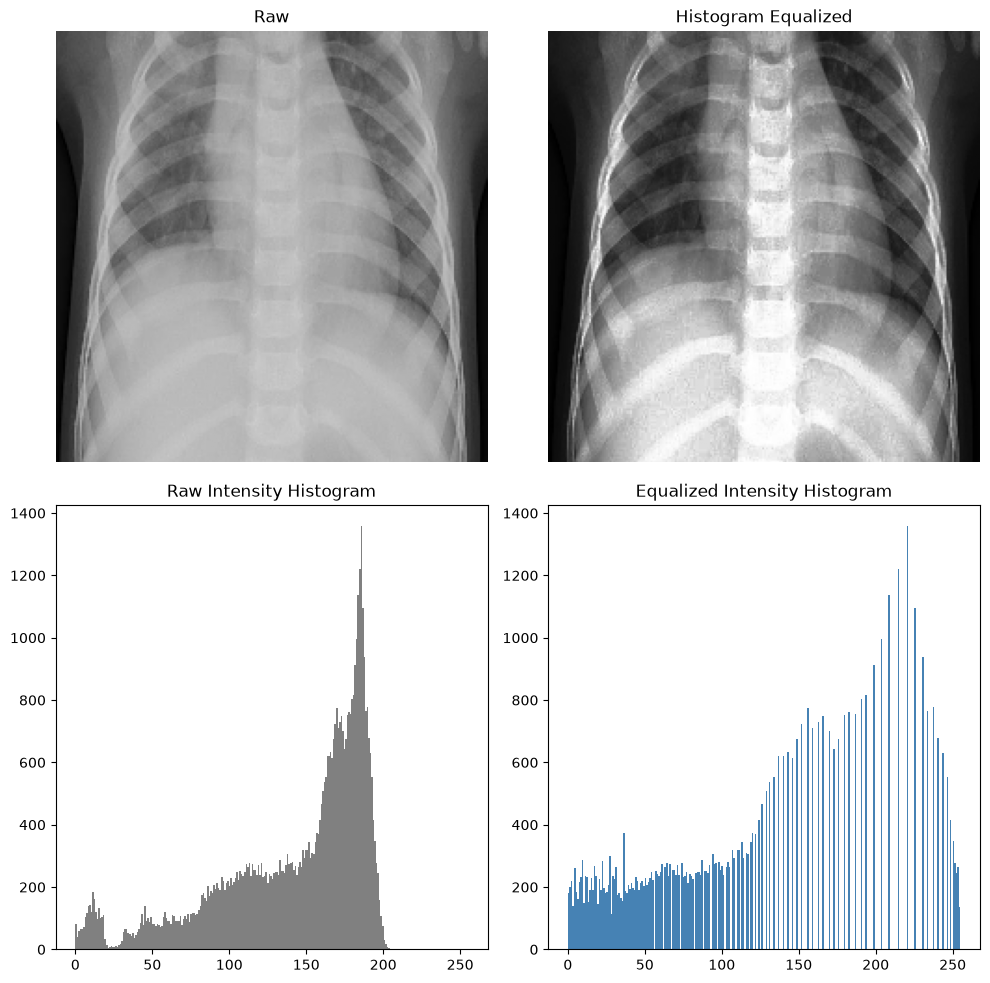

In [3]:
equalized = cv2.equalizeHist(raw)



fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(raw, cmap='gray', vmin=0, vmax=255)

axes[0, 0].set_title('Raw')

axes[0, 0].axis('off')



axes[0, 1].imshow(equalized, cmap='gray', vmin=0, vmax=255)

axes[0, 1].set_title('Histogram Equalized')

axes[0, 1].axis('off')



axes[1, 0].hist(raw.ravel(), bins=256, range=(0, 255), color='gray')

axes[1, 0].set_title('Raw Intensity Histogram')



axes[1, 1].hist(equalized.ravel(), bins=256, range=(0, 255), color='steelblue')

axes[1, 1].set_title('Equalized Intensity Histogram')



plt.tight_layout()

plt.savefig(f'{OUTPUT_DIR}/02_histogram_equalization.png', bbox_inches='tight')

plt.show()

**Observation:** the raw histogram is crowded into a narrow dark band, so rib and lung-field boundaries are barely distinguishable. After equalization the histogram spreads across the full range and previously invisible structures (rib edges, lung field boundaries, mediastinum) become visible.

## 3. Color Mapping

Mapping equalized intensity to a false-color spectrum (`COLORMAP_JET`) helps the human eye separate subtle intensity differences that look identical in grayscale, such as faint fluid boundaries.

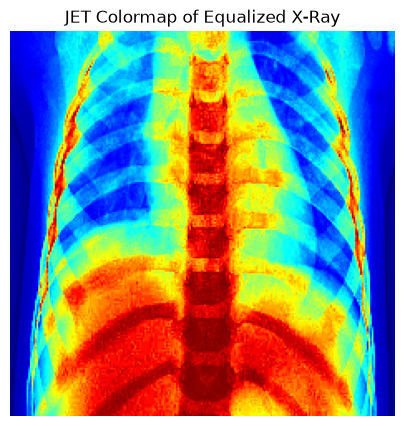

In [4]:
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)

heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)



plt.figure(figsize=(5, 5))

plt.imshow(heatmap_rgb)

plt.title('JET Colormap of Equalized X-Ray')

plt.axis('off')

plt.savefig(f'{OUTPUT_DIR}/03_colormap_jet.png', bbox_inches='tight')

plt.show()

## 4. Color Balance

A gray-world white balance neutralizes artificial color casts: it rescales each BGR channel so the three channel means match, correcting any tint introduced by the colormap step.

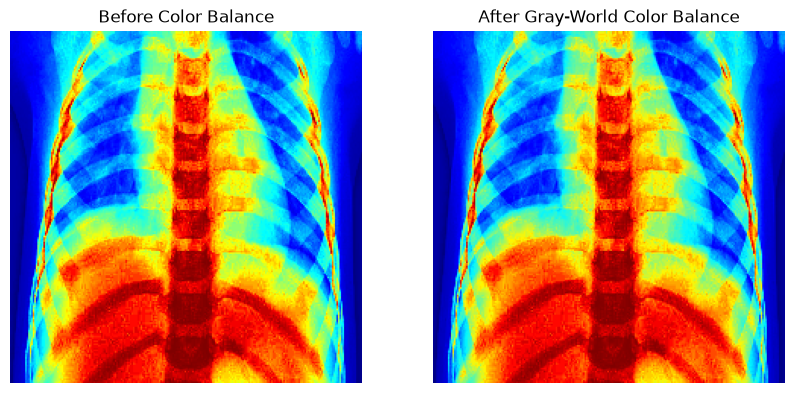

In [5]:
def gray_world_balance(bgr_image):

    b, g, r = cv2.split(bgr_image.astype(np.float64))

    gray_mean = (b.mean() + g.mean() + r.mean()) / 3.0

    b = np.clip(b * (gray_mean / (b.mean() + 1e-6)), 0, 255)

    g = np.clip(g * (gray_mean / (g.mean() + 1e-6)), 0, 255)

    r = np.clip(r * (gray_mean / (r.mean() + 1e-6)), 0, 255)

    return cv2.merge([b, g, r]).astype(np.uint8)





balanced = gray_world_balance(heatmap)

balanced_rgb = cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB)



fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(heatmap_rgb)

axes[0].set_title('Before Color Balance')

axes[0].axis('off')

axes[1].imshow(balanced_rgb)

axes[1].set_title('After Gray-World Color Balance')

axes[1].axis('off')

plt.savefig(f'{OUTPUT_DIR}/04_color_balance.png', bbox_inches='tight')

plt.show()

## 5. Color Filtering (Thresholding)

Dense tissue (bone, dense fluid) reflects the highest intensities in the equalized matrix. We threshold at the 90th percentile of intensity, so only the densest ~10% of tissue survives the mask, then use that mask to isolate those regions in the colored heatmap.

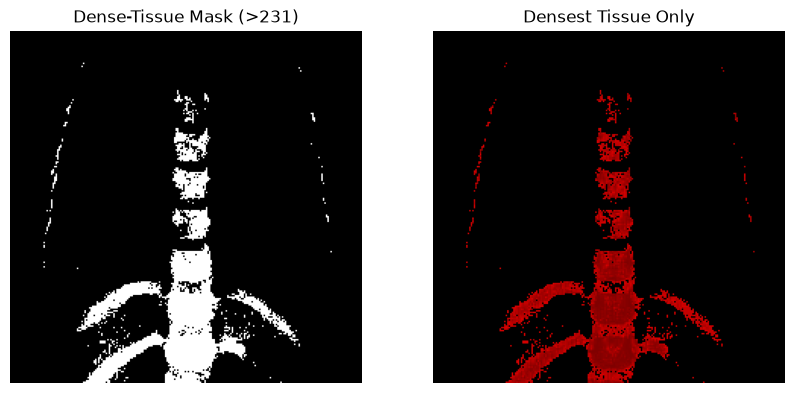

In [6]:
dense_tissue_cutoff = np.percentile(equalized, 90)

_, dense_mask = cv2.threshold(equalized, dense_tissue_cutoff, 255, cv2.THRESH_BINARY)

masked_heatmap = cv2.bitwise_and(heatmap, heatmap, mask=dense_mask)

masked_heatmap_rgb = cv2.cvtColor(masked_heatmap, cv2.COLOR_BGR2RGB)



fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(dense_mask, cmap='gray')

axes[0].set_title(f'Dense-Tissue Mask (>{dense_tissue_cutoff:.0f})')

axes[0].axis('off')

axes[1].imshow(masked_heatmap_rgb)

axes[1].set_title('Densest Tissue Only')

axes[1].axis('off')

plt.savefig(f'{OUTPUT_DIR}/05_threshold_mask.png', bbox_inches='tight')

plt.show()

## 6. Logarithmic Transformation

Applied to the **raw** image, the log curve expands dark background regions logarithmically, revealing faint outer rib edges that a linear stretch would leave crushed near zero.

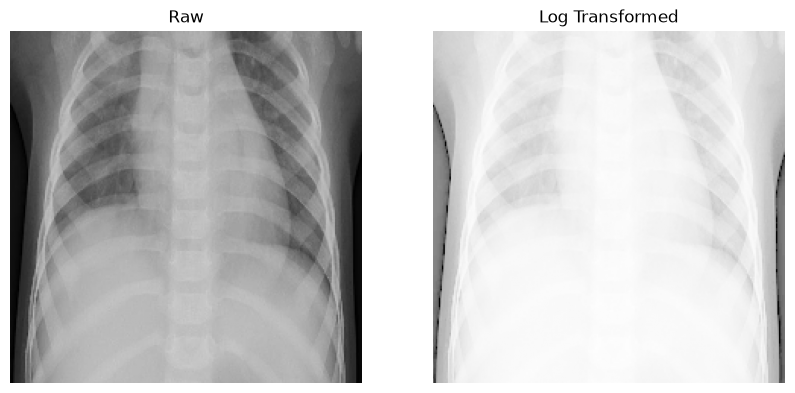

In [7]:
def log_transform(image):

    image_f = image.astype(np.float64)

    c = 255.0 / np.log(1 + image_f.max())

    result = c * np.log(1 + image_f)

    return np.clip(result, 0, 255).astype(np.uint8)





log_img = log_transform(raw)



fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(raw, cmap='gray', vmin=0, vmax=255)

axes[0].set_title('Raw')

axes[0].axis('off')

axes[1].imshow(log_img, cmap='gray', vmin=0, vmax=255)

axes[1].set_title('Log Transformed')

axes[1].axis('off')

plt.savefig(f'{OUTPUT_DIR}/06_log_transform.png', bbox_inches='tight')

plt.show()

## 7. Power-Law (Gamma) Transformation

A fractional gamma (< 1.0) applied to the raw image brightens midtones non-linearly, softening the harsh bone contrast so soft lung tissue becomes easier to read without blowing out highlights.

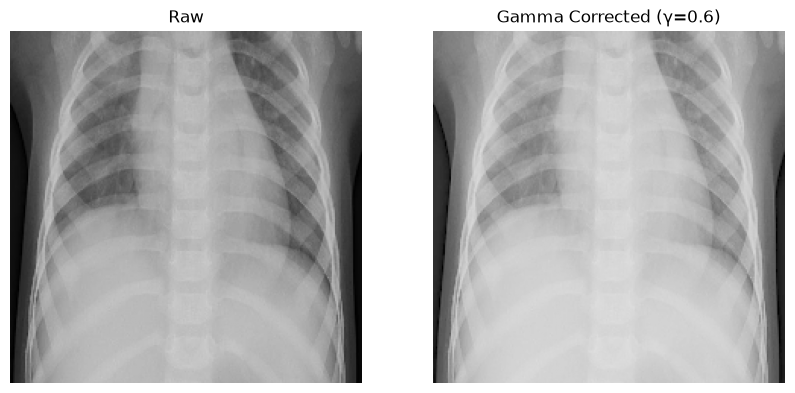

In [8]:
def gamma_transform(image, gamma=0.6):

    normalized = image.astype(np.float64) / 255.0

    result = 255.0 * np.power(normalized, gamma)

    return np.clip(result, 0, 255).astype(np.uint8)





gamma_img = gamma_transform(raw, gamma=0.6)



fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(raw, cmap='gray', vmin=0, vmax=255)

axes[0].set_title('Raw')

axes[0].axis('off')

axes[1].imshow(gamma_img, cmap='gray', vmin=0, vmax=255)

axes[1].set_title('Gamma Corrected (\u03b3=0.6)')

axes[1].axis('off')

plt.savefig(f'{OUTPUT_DIR}/07_gamma_transform.png', bbox_inches='tight')

plt.show()

## Summary

- Histogram equalization revealed rib and lung-field structure hidden in the narrow raw intensity band.

- The JET colormap and gray-world balance made subtle intensity differences perceptible to the eye without an artificial color cast.

- Percentile thresholding isolated only the densest tissue (bone / dense fluid).

- The log transform recovered faint dark-background detail; the gamma transform (\u03b3=0.6) softened bone contrast to make soft tissue clearer.

- All enhanced views are saved under `output/` for review.